In [ ]:
# In particular, a research group in Computer Science at UBC, led by Frank Wood, is collecting data about how people play
# video games. They have set up a MineCraft server, and players' actions are recorded as they navigate through the world. 
# But running this project is not simple: they need to target their recruitment efforts, and make sure they have enough resources
# (e.g., software licenses, server hardware) to handle the number of players they attract.

In [ ]:
# submit as .html and as .ipynb
# max 500 words (non-inclusive of code)
# should not require other files (no reading in data, just name variables & etc)

# chosen question (Question 2):
# We would like to know which "kinds" of players are most likely to contribute
# a large amount of data so that we can target those players in our recruiting efforts.

# should only need players.csv to answer this question

In [1]:
# the problem (dissected):
# "contribute a large amount of data" = high played hours
# predicting high played hours based on other qualities = k-nn regression
# player data -> -> k-nn regression

In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


**1. Data Description**
The dataset I am using, `players.csv`, has 196 observations with 7 variables. The variables are described in the table below:

In [18]:
variable_desc_table <- data.frame(
    name = c("experience", "subscribe", "hashedEmail", "played_hours", "name", "gender", "Age"),
    type = c("character", "logical", "character", "double", "character", "character", "double"),
    mean_stat_if_dbl = c("NA", "NA", "NA", "5.85", "NA", "NA", "21.14"),
    description = c("The experience level of the player in playing Minecraft (Beginner, Amateur, Regular, Pro, 
                    Veteran)", "If the player is subscribed to the gaming newsletter", "Anonymous representation
                    of player's email address", "Hours played on Minecraft server", "Player's first name", "Player's 
                    gender (Male, Female, Non-binary, Two-Spirited, Agender, Prefer not to say, Other)", "Player's age")
    )
variable_desc_table

name,type,mean_stat_if_dbl,description
<chr>,<chr>,<chr>,<chr>
experience,character,NA,"The experience level of the player in playing Minecraft (Beginner, Amateur, Regular, Pro, Veteran)"
subscribe,logical,NA,If the player is subscribed to the gaming newsletter
hashedEmail,character,NA,Anonymous representation of player's email address
played_hours,double,5.85,Hours played on Minecraft server
name,character,NA,Player's first name
gender,character,NA,"Player's gender (Male, Female, Non-binary, Two-Spirited, Agender, Prefer not to say, Other)"
Age,double,21.14,Player's age


The only issue that comes to mind when dealing with the data is the use of the hashed emails as the only real unique distinctive value between each observation, since they are such long and random character strings that aren't easy for humans to read. While I couldn't see any duplicate player names, it is still possible I missed one given the number of observations, so it is not a good variable to use for this. However, I do not forsee a need to filter for an individual observation often (if at all), so I am not concerned. Additionally, I noticed there are some seemingly odd name and gender pairings, given societal naming conventions, which could be indicative of the data being transferred to the `.csv` file incorrectly. That is the only reason I note it, but there are likely other explanations, so I assume it to be a non-issue in the meantime. Lastly, some observations have `NA` in the `Age` variable, but that is easy to resolve with filtration. 

I cannot see how the data was collected, but my assumption is that player identity it was through an email survey form based on the hashed emails, and then some other program likely used that identity data to track hours of play per player. The most important variable here is the played hours, as it is what will be used to represent the amount of data a player contributes to the study (more hours = more data). The other variables will be used to predict the hours played via a regression model.

In [19]:
players <- read_csv("data/players.csv")

summary_stats <- summarize(players, 
                           avg_played_hours = mean(played_hours, na.rm = TRUE),
                           avg_age = mean(Age, na.rm = TRUE))
summary_stats

avg_played_hours,avg_age
<dbl>,<dbl>
5.845918,21.13918


**2. Questions**

Broad question: *What "kinds" of players are most likely to contribute the most amount of data to the study by contributing higher hours of play?*

My specific questions:
- Can player age help predict hours of play on the Minecraft server?
- Does gender help predict hours of play on the Minecraft server?
- Can player experience help predict hours of play on the Minecraft server?
- Which of the prior 3 variables is the strongest predictor for hours of play?
- What is the mode gender and experience level as well as the mode age range (by ranges <18, 18-20, 21-24, >24) of the top 10 players by hours contributed?

The data will help me explore the broader question and its more specific questions by providing values for the variables of age, gender, experience, and hours played in observations that relate them together. I will need to use filtration to wrangle the data to answer some of my questions to filter out `NA`s, select for the 10 players with the highest play time, and to filter for other qualities such as certain ages.

**3. Exploratory Data Analysis and Visualization**

See cell 19 for where I read in the dataset.

In [20]:
head(players)

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


The data set already meets the requirements for tidy data based on the research question:

1. Each observation is a single row.
2. Each column is a single variable (and all variables for the statistical questions are in columns, not as values).
3. Each cell contains a single value.

The `sessions.csv` file, which is irrelevant to these questions, does have issues with the start and end time variables, as they contain year, month, day, AND time in a single cell. The start and end times would need to be widened with `pivot_widen()` into separate variables for each component, but that is not the dataset I am using.

In [58]:
# minimum wrangling: remove NA, remove players who contribute no data, remove names and subscription status
tidy_players <- players |>
    filter(!is.na(Age)) |>
    filter(played_hours != 0) |>
    select(experience, hashedEmail, played_hours, gender, Age)

tidy_players

experience,hashedEmail,played_hours,gender,Age
<chr>,<chr>,<dbl>,<chr>,<dbl>
Pro,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Male,9
Veteran,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Male,17
Amateur,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Female,21
Regular,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Male,21
Amateur,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Male,47
Veteran,7a4686586d290c67179275c7c3dfb4ea02f4d317d9ee0e2cee98baa27877a875,1.6,Female,23
Beginner,4bed6f49b672974f706aa7f020b4f29020326bf594520593557cd381a51559b8,1.5,Female,25
Amateur,3caa832978e0596779f4ee7c686c4592fb6de893925025d25bf26be9a8cd03f5,0.2,Male,22
Amateur,a175d4741dc84e6baf77901f6e8e0a06f54809a34e6b5211159bced346f7fb3e,48.4,Female,17


In [59]:
# mean values for each quantitative variable
mean_values_players <- tidy_players |>
    summarize(
        mean_played_hours = mean(played_hours),
        mean_age = mean(Age)
        )
mean_values_players

mean_played_hours,mean_age
<dbl>,<dbl>
10.50917,21.30275


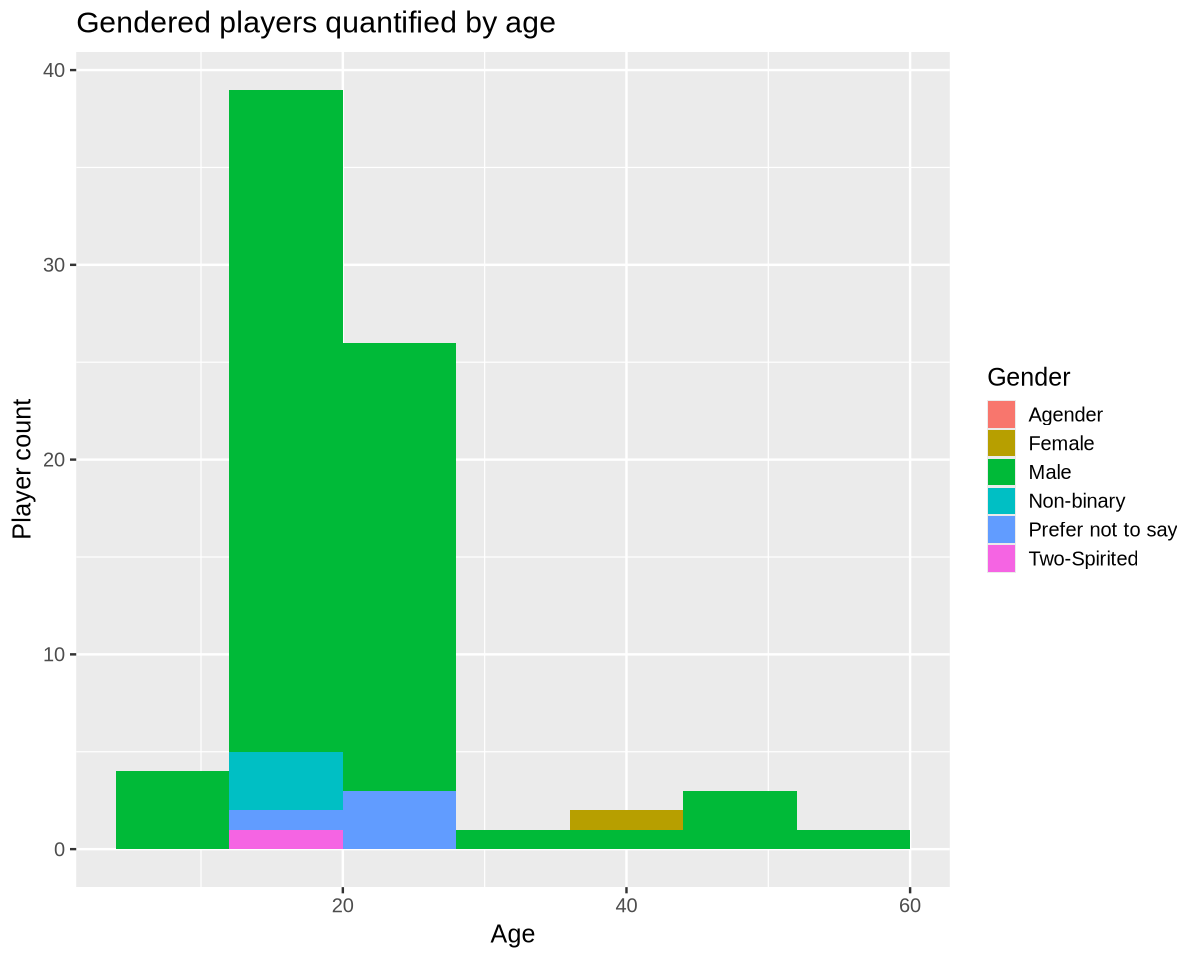

In [60]:
theme_set(theme_gray(base_size = 15))
# histogram visualization: quantities of people by age with colour distinction for gender
options(repr.plot.width = 10, repr.plot.height = 8)
age_count_plot <- ggplot(tidy_players, aes(x = Age, fill = gender)) +
    geom_histogram(position = "identity", binwidth = 8) +
    ggtitle("Gendered players quantified by age") +
    labs(x = "Age", y = "Player count", fill = "Gender")  

age_count_plot

This plot gives me insight into the demographics of this dataset regarding age and gender. From this histogram, I can see that an overwhelming majority of players are male and between the ages of 10-30. This uneven demographic could make it difficult to assess how well gender and age actually predict hours of play due to imbalance. Not all gender identity options are present across each demographic either, which makes it difficult to find commonalities between age and gender as predictors.

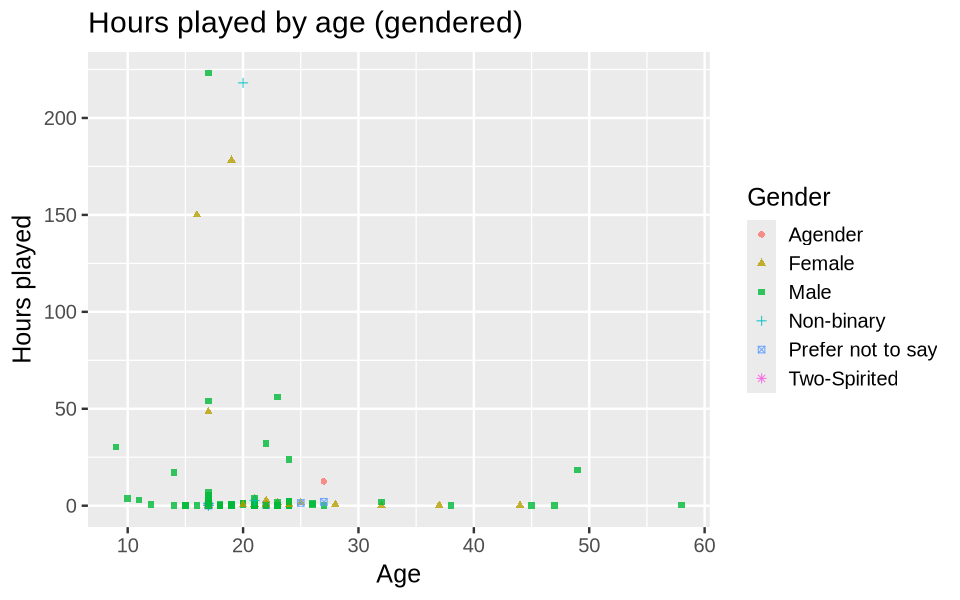

In [61]:
# scatter plot visualization: age versus hours played
options(repr.plot.width = 8, repr.plot.height = 5)
age_hours_played_plot <- ggplot(tidy_players, aes(x = Age, y = played_hours, color = gender, shape = gender)) +
    geom_point(alpha = 0.8) +
    ggtitle("Hours played by age (gendered)") +
    labs(x = "Age", y = "Hours played", color = "Gender", shape = "Gender")

age_hours_played_plot

This plot allows me to expand on the previous visualization and see what genders and ages contribute the most hours. There is a weak negative relationship between age and hours played. For hours above 25, 5 players are male, 3 are female, 1 is non-binary, and they are all people who are under 25. This further supports the difficulty in using a prediction model on this data. The `k-nn` regression model will not be a good fit, so linear regression will likely be more suited, but there are still imbalance concerns.

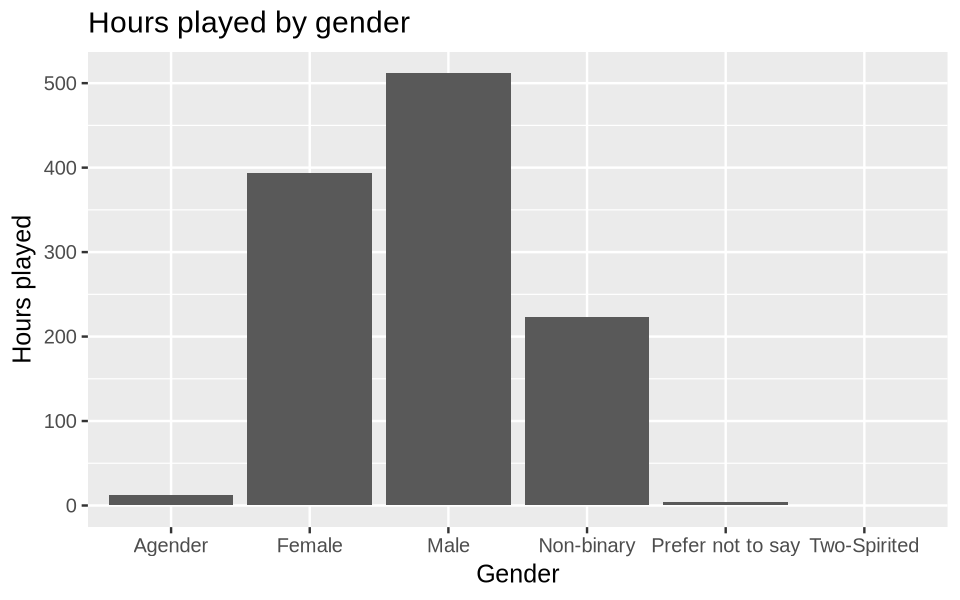

In [65]:
# bar plot visualization: gender versus hours played
options(repr.plot.width = 8, repr.plot.height = 5)
gender_hours_played_plot <- ggplot(tidy_players, aes(x = gender, y = played_hours)) +
    geom_bar(stat = "identity") +
    ggtitle("Hours played by gender") +
    labs(x = "Gender", y = "Hours played")

gender_hours_played_plot

This bar graph gives me better insight into hours played per gender identity, and from this visual, it is apparent that hours by gender are slightly less imbalanced in that it is not almost entirely from males, but there are still large gaps between certain identities. 

The overall insights that do benefit the project are that while age is not a great indicative of hours played due to extremely uneven data across ages, gender may be a better predictor of if a player will contribute more data to the study.

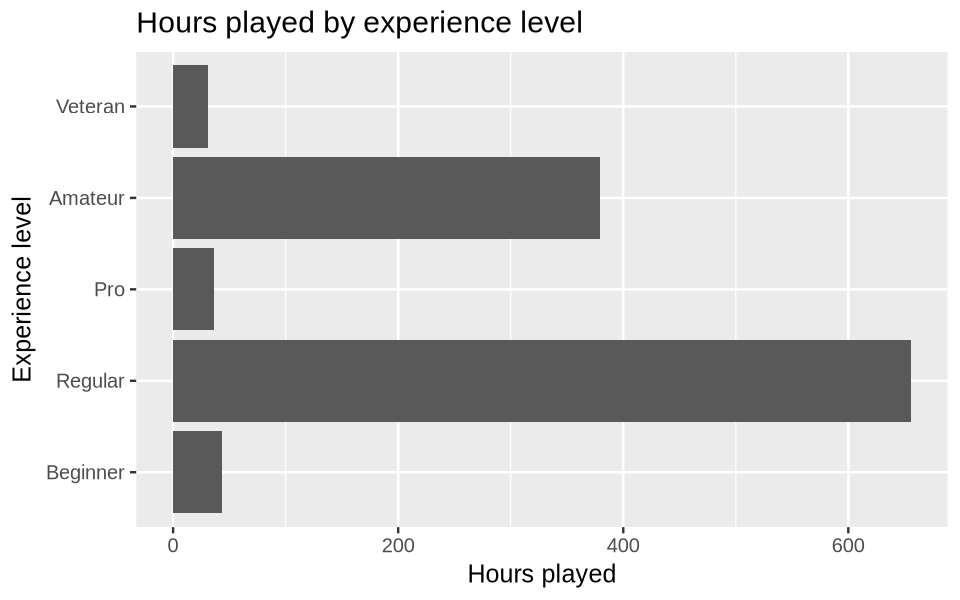

In [77]:
# bar plot visualization: experience level versus hours played
# note: this dataset needs more wrangling to display the bars in descending order of hours played
options(repr.plot.width = 8, repr.plot.height = 5)
experience_hours_played_plot <- ggplot(tidy_players, 
                                       aes(x = played_hours,
                                           y = fct_reorder(experience, played_hours, .desc = TRUE)
                                          )) +
    geom_bar(stat = "identity") +
    ggtitle("Hours played by experience level") +
    labs(y = "Experience level", x = "Hours played")

experience_hours_played_plot 

This bar graph looks at experience level as a potential predictor of hours played, which looks to have more promise than age, but it is necessary to assess the histogram recolored for experience balance:

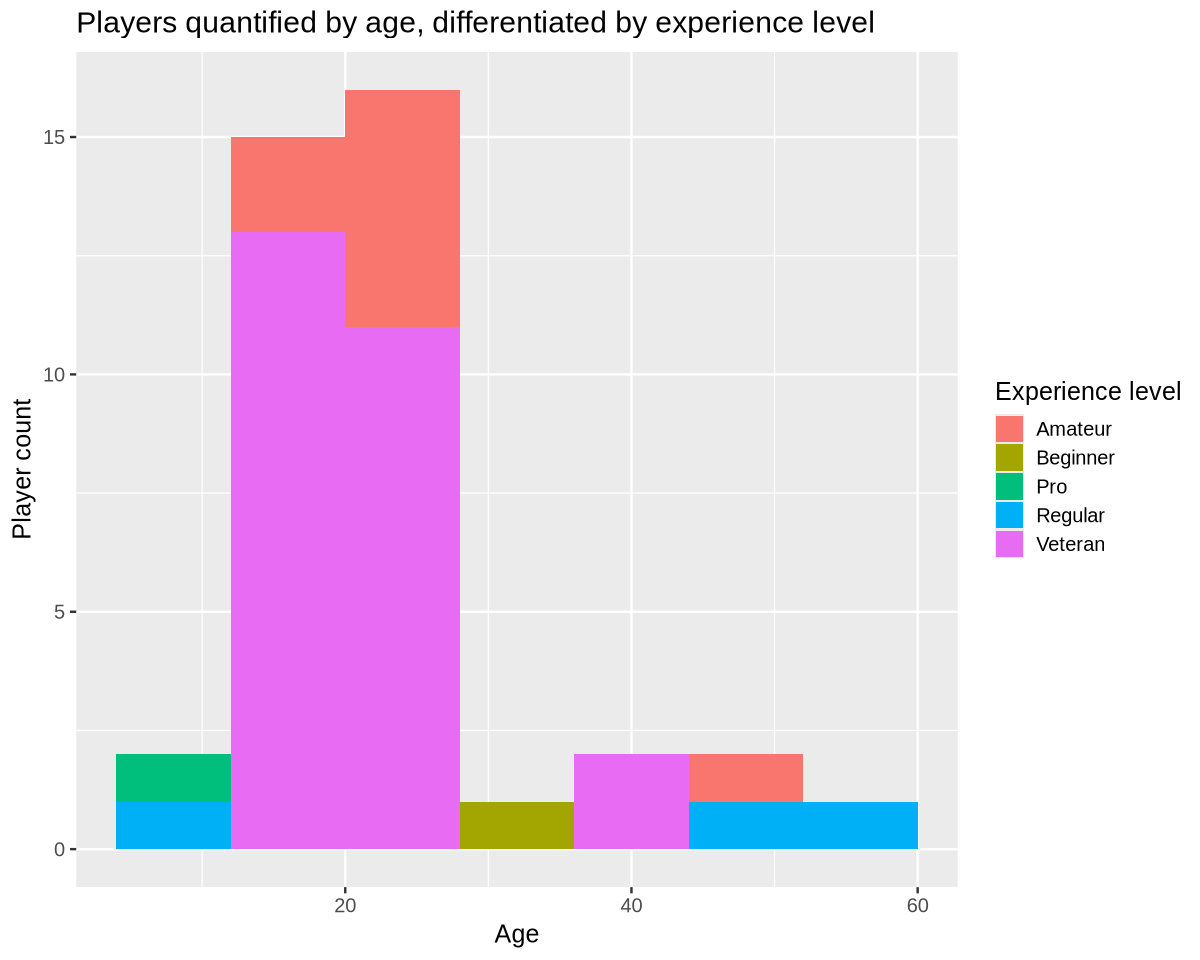

In [78]:
# histogram visualization: quantities of people by age with colour distinction for experience level
options(repr.plot.width = 10, repr.plot.height = 8)
age_count_plot_exp <- ggplot(tidy_players, aes(x = Age, fill = experience)) +
    geom_histogram(position = "identity", binwidth = 8) +
    ggtitle("Players quantified by age, differentiated by experience level") +
    labs(x = "Age", y = "Player count", fill = "Experience level")  

age_count_plot_exp

The final insight gained is that most players in the study are veterans. This is also demographically imbalanced.

The data does have players who played 0 hours filtered out, which may affect the histograms and show that there is less demographic imbalance than shown here, but considering the question explores who contributes the most data, it makes sense to filter for the people who contribute any data to begin with.